In [ ]:
# Task 2: Unemployment Analysis with Python

# Objective

The objective of this project is to perform exploratory data analysis
on unemployment data in India to identify regional and temporal trends
and analyze the impact of the COVID-19 pandemic on unemployment rates.

#Technologies Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Set plotting style
sns.set_style("whitegrid")

In [3]:
from google.colab import files

uploaded = files.upload()

# Load dataset
df = pd.read_csv("Unemployment in India.csv")

# Display first 5 rows
df.head(5)

Saving Unemployment in India.csv to Unemployment in India (1).csv


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [5]:
print("Dataset Shape:", df.shape)

Dataset Shape: (768, 7)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [9]:
print("Null values:")
print(df.isnull().sum())

Null values:
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


In [12]:
df = df.dropna().copy()

In [14]:
print(df.isnull().sum())

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64


In [16]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [18]:
df = df.rename(columns={
    "Region": "Region",
    "Date": "Date",
    "Estimated Unemployment Rate (%)": "Unemployment_Rate",
    "Estimated Employed": "Employed",
    "Estimated Labour Participation Rate (%)": "Labour_Participation_Rate"
})

df.head()

,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [20]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Sort by date
df = df.sort_values("Date")

print(df["Date"].dtype)

datetime64[ns]


In [22]:
df.describe()

,Date,Unemployment_Rate,Employed,Labour_Participation_Rate
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [24]:
region_avg = (
    df.groupby("Region")["Unemployment_Rate"]
    .mean()
    .sort_values(ascending=False)
)

region_avg

,Unemployment_Rate
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


In [ ]:
### Observation

The regional analysis shows that unemployment rates vary considerably
across Indian regions. Some regions have substantially higher average
unemployment rates than others, indicating differences in labour-market
conditions.

In [30]:
monthly_avg = (
    df.groupby("Date")["Unemployment_Rate"]
    .mean()
    .reset_index()
)

monthly_avg.head()

,Date,Unemployment_Rate
0,2019-05-31,8.874259
1,2019-06-30,9.303333
2,2019-07-31,9.033889
3,2019-08-31,9.637925
4,2019-09-30,9.051731


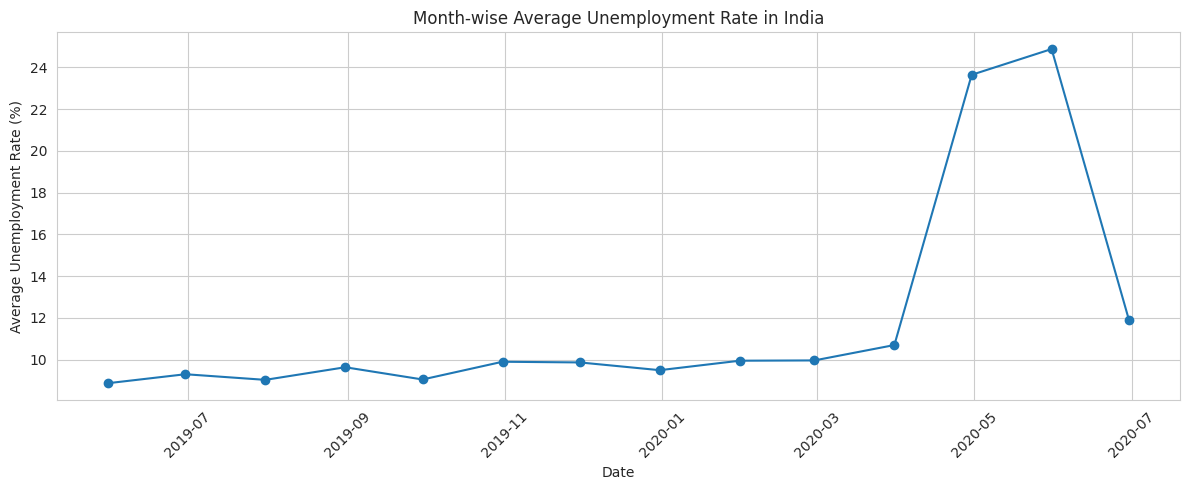

In [32]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_avg["Date"],
    monthly_avg["Unemployment_Rate"],
    marker="o"
)

plt.title("Month-wise Average Unemployment Rate in India")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Observation

The monthly trend shows how unemployment changed over time.
A noticeable increase can be observed around the COVID-19 period,
indicating the effect of the pandemic on employment conditions.

In [34]:
print(df["Region"].unique())

['Andhra Pradesh' 'Maharashtra' 'Jharkhand' 'Jammu & Kashmir'
 'Himachal Pradesh' 'Meghalaya' 'Haryana' 'Gujarat' 'Goa' 'Odisha' 'Delhi'
 'Chandigarh' 'Karnataka' 'Puducherry' 'Assam' 'Punjab' 'West Bengal'
 'Uttar Pradesh' 'Sikkim' 'Chhattisgarh' 'Bihar' 'Kerala' 'Uttarakhand'
 'Madhya Pradesh' 'Tamil Nadu' 'Rajasthan' 'Telangana' 'Tripura']


In [36]:
selected_regions = [
    "Andhra Pradesh",
    "Bihar",
    "Delhi"
]

filtered_df = df[df["Region"].isin(selected_regions)]

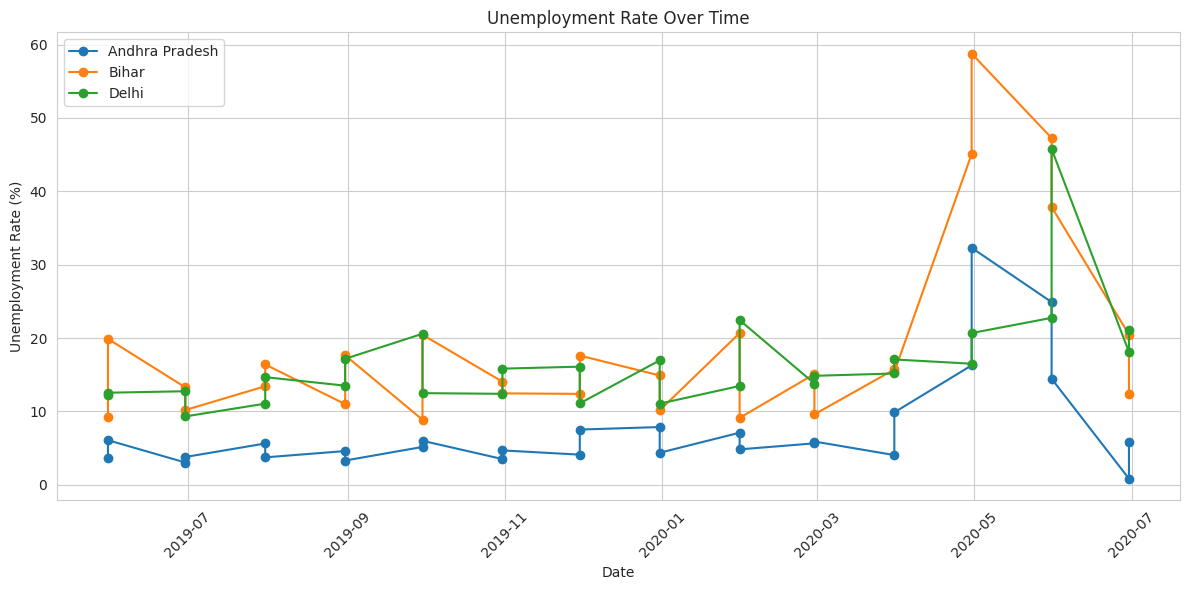

In [37]:
plt.figure(figsize=(12, 6))

for region in selected_regions:
    region_data = filtered_df[filtered_df["Region"] == region]

    plt.plot(
        region_data["Date"],
        region_data["Unemployment_Rate"],
        marker="o",
        label=region
    )

plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Observation

The time-series comparison shows that unemployment rates did not
change uniformly across the three regions. Each region experienced
different levels of fluctuation over time, with major changes occurring
during the COVID-19 period.

In [39]:
top_10 = (
    df.groupby("Region")["Unemployment_Rate"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_10

,Unemployment_Rate
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


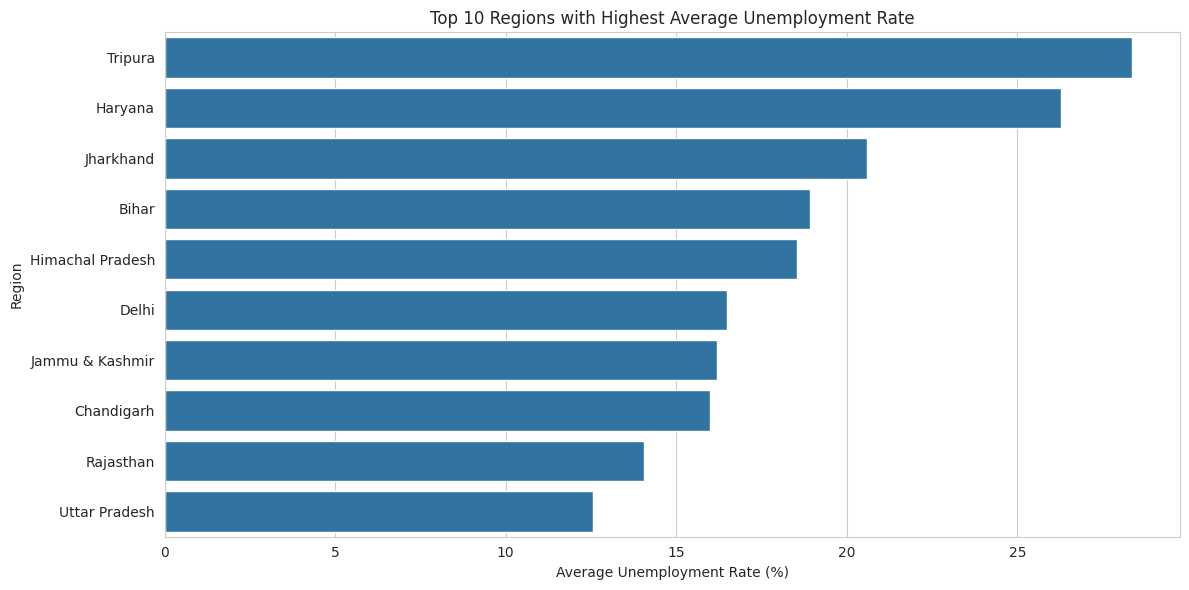

In [41]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_10.values,
    y=top_10.index
)

plt.title("Top 10 Regions with Highest Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

In [ ]:
# Observation

The bar chart identifies the ten regions with the highest average
unemployment rates. The results indicate that unemployment was not
uniform across India, with some regions experiencing considerably
higher average unemployment than others.

In [43]:
correlation_data = df[
    [
        "Unemployment_Rate",
        "Employed",
        "Labour_Participation_Rate"
    ]
]

correlation_matrix = correlation_data.corr()

correlation_matrix

,Unemployment_Rate,Employed,Labour_Participation_Rate
Unemployment_Rate,1.000000,-0.222876,0.002558
Employed,-0.222876,1.000000,0.011300
Labour_Participation_Rate,0.002558,0.011300,1.000000


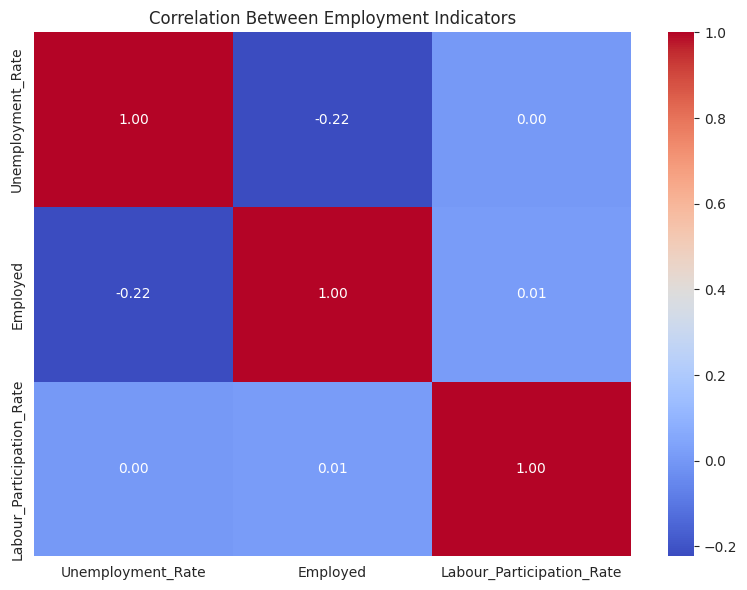

In [47]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Employment Indicators")
plt.tight_layout()
plt.show()

In [ ]:
# Observation

The correlation heatmap shows the relationship between unemployment,
employment and labour participation.

A positive correlation means that two variables tend to increase
together, while a negative correlation means that one variable tends
to decrease as the other increases.

Correlation indicates association and should not be interpreted as
proof of causation.

In [48]:
covid_date = pd.Timestamp("2020-03-01")

pre_covid = df[df["Date"] < covid_date]
post_covid = df[df["Date"] >= covid_date]

In [50]:
print("Pre-COVID records:", len(pre_covid))
print("Post-COVID records:", len(post_covid))

Pre-COVID records: 536
Post-COVID records: 204


In [51]:
comparison = pd.DataFrame({
    "Period": ["Pre-COVID", "Post-COVID"],
    "Average Unemployment Rate": [
        pre_covid["Unemployment_Rate"].mean(),
        post_covid["Unemployment_Rate"].mean()
    ],
    "Average Labour Participation Rate": [
        pre_covid["Labour_Participation_Rate"].mean(),
        post_covid["Labour_Participation_Rate"].mean()
    ]
})

comparison

,Period,Average Unemployment Rate,Average Labour Participation Rate
0,Pre-COVID,9.509534,43.886119
1,Post-COVID,17.774363,39.330049


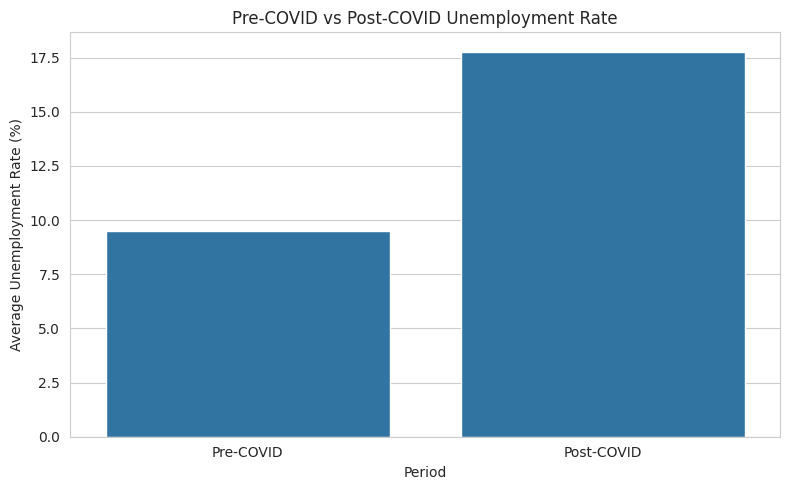

In [52]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x="Period",
    y="Average Unemployment Rate"
)

plt.title("Pre-COVID vs Post-COVID Unemployment Rate")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")

plt.tight_layout()
plt.show()

In [ ]:
# Observation

The comparison between the two periods shows a clear difference in
average unemployment rates. The COVID-19 period was associated with
substantial disruption to employment and labour-market activity in
India.

The post-COVID period should therefore be interpreted as a period
affected by the pandemic rather than as a completely independent
economic period.

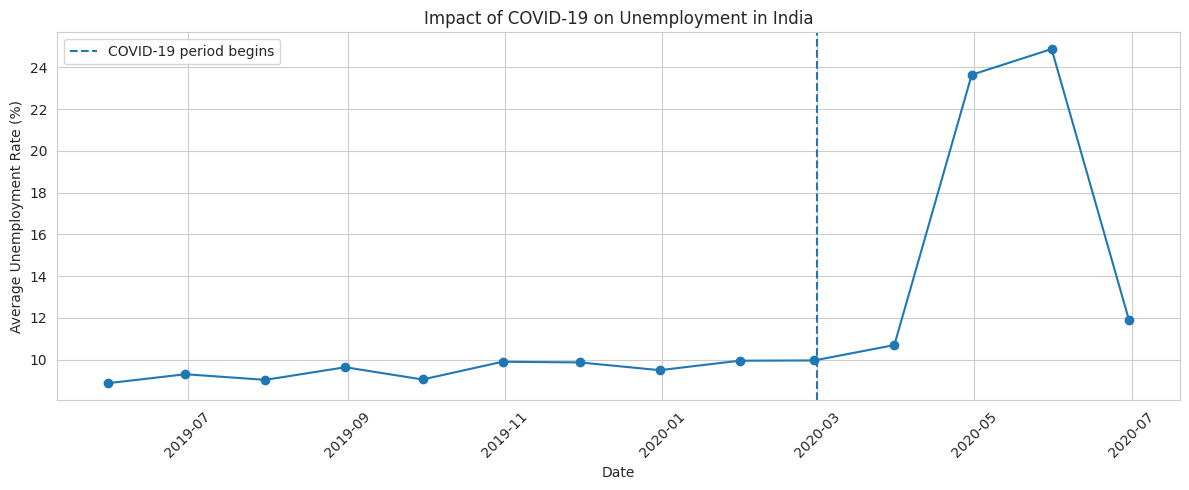

In [53]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_avg["Date"],
    monthly_avg["Unemployment_Rate"],
    marker="o"
)

plt.axvline(
    pd.Timestamp("2020-03-01"),
    linestyle="--",
    label="COVID-19 period begins"
)

plt.title("Impact of COVID-19 on Unemployment in India")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Observation

The time-series visualization helps identify changes in unemployment
around the beginning of the COVID-19 period. The sharp movement in
unemployment during this period suggests significant labour-market
disruption.

In [ ]:
# Conclusion

This exploratory data analysis examined unemployment trends in India
using regional and time-series data.

The analysis produced several important findings:

1. Average unemployment rates vary considerably across regions,
   indicating differences in regional labour-market conditions.

2. Monthly analysis shows significant changes in unemployment rates
   over time.

3. The time-series comparison of selected regions demonstrates that
   unemployment trends were not identical across states.

4. The top-10 analysis identifies the regions with the highest average
   unemployment rates.

5. Correlation analysis shows the statistical relationships between
   unemployment rate, employment and labour participation rate.

6. The pre-COVID and post-COVID comparison indicates that the
   unemployment situation changed substantially during the COVID-19
   period.

